In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))
from paths import PROCESSED, RESULTS, savefig
from pypsa_helpers import (
    require_optimal,
    cost_by_technology,
    capacity_by_technology,
    electricity_mix,
    co2_shadow_price,
    curtailment_rate,
    electricity_buses,
)

import pypsa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Sensitivity Analysis Results: Electrolysis Capital Cost (Zero-CO2 Scenario)

Covers the zero-CO2 scenario family only (the CO2 shadow price only exists where the CO2
constraint is actually binding): the 100% cost level *is* the `08_scenario_100pct_co2_reduction`
baseline, plus the 75/50/25/0% electrolysis capital cost variants from `09_sensitivity_electrolysis_cost`.

- Cost/capacity/electricity-mix/CO2-shadow-price **comparison tables** cover every level that
  has successfully solved (missing levels are skipped with a warning, not an error).
- The deeper per-timestep diagnostics (price duration curves, regional prices, curtailment,
  storage filling, representative-week operation) are built for two representative cases only:
  **100% (baseline)** and **0% (free electrolysis)** cost, since building all five would mostly
  produce near-duplicate plots.

In [2]:
levels = [100, 75, 50, 25, 0]
networks = {}

for level in levels:
    path = PROCESSED / f"pypsa_sensitivity_electrolysis_{level}pct.nc"
    if not path.exists():
        print(f"SKIPPING {level}% - not solved yet ({path.name} not found)")
        continue
    net = pypsa.Network(str(path))
    require_optimal(net)  # belt-and-braces: only export_to_netcdf'd after this passed anyway
    networks[level] = net

cost_scale = next(iter(networks.values())).meta["cost_scale"]
print("loaded levels:", sorted(networks.keys(), reverse=True))

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.1.2)


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, stores, sub_networks


INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.1.2)


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, stores, sub_networks


INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.1.2)


...

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.1.2)


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, stores, sub_networks


INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.1.2)


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, stores, sub_networks


loaded levels: [100, 75, 50, 25, 0]


## 1. Total System Cost, Split by Technology

In [3]:
cost_table = pd.DataFrame(
    {level: cost_by_technology(net, cost_scale).sum(axis=1) for level, net in networks.items()}
).fillna(0)
cost_table = cost_table[sorted(cost_table.columns, reverse=True)]
cost_table.columns = [f"{c}%" for c in cost_table.columns]
cost_table.index.name = "technology"

cost_table

,100%,75%,50%,25%,0%
technology,,,,,
AC,1.382092e+08,1.312270e+08,1.402234e+08,1.537486e+08,1.269648e+08
CCGT,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
H2 electrolysis,3.429562e+08,3.218129e+08,3.144450e+08,2.500582e+08,0.000000e+00
H2 fuel cell,1.792500e+09,1.840561e+09,1.968132e+09,2.021874e+09,2.066088e+09
H2 store,5.756953e+08,6.033439e+08,6.362345e+08,5.128272e+08,3.159707e+08
battery,1.566288e+09,1.454528e+09,1.256336e+09,1.219230e+09,1.188661e+09
hydro,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
onwind,1.358761e+09,1.304622e+09,1.367426e+09,1.413943e+09,1.609163e+09
solar,2.109143e+09,2.134739e+09,1.974637e+09,1.873126e+09,1.742177e+09


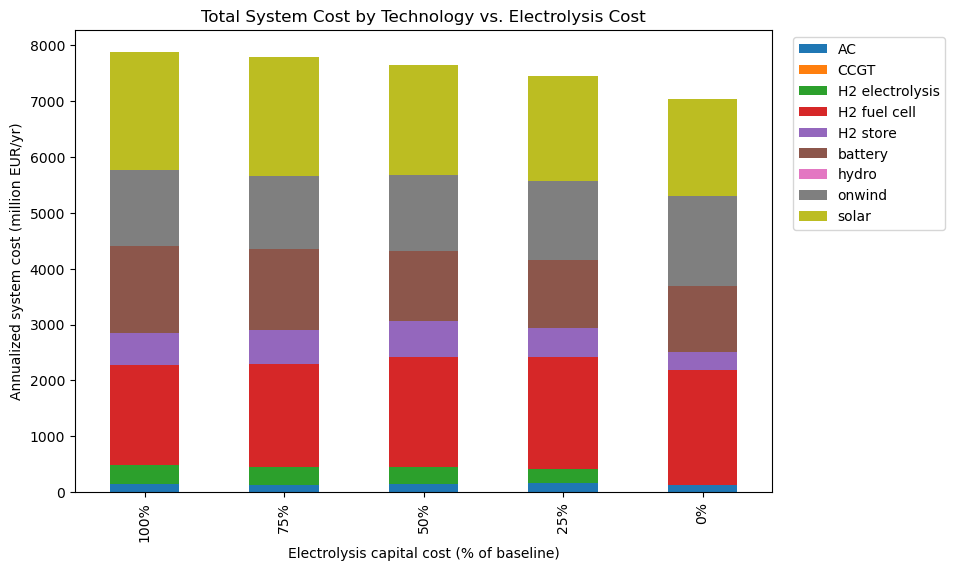

In [4]:
fig, ax = plt.subplots(figsize=(9, 6))
(cost_table.T / 1e6).plot.bar(stacked=True, ax=ax)
ax.set_ylabel("Annualized system cost (million EUR/yr)")
ax.set_xlabel("Electrolysis capital cost (% of baseline)")
ax.set_title("Total System Cost by Technology vs. Electrolysis Cost")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

savefig(fig, "sensitivity", "cost_by_technology.png")
plt.show()

## 2. Capacities Built per Technology

Power capacities (MW) and the H2 store's energy capacity (MWh) are shown separately since
they're different units and would otherwise be misleading stacked together.

In [5]:
capacity_table = pd.DataFrame(
    {level: capacity_by_technology(net) for level, net in networks.items()}
).fillna(0)
capacity_table = capacity_table[sorted(capacity_table.columns, reverse=True)]
capacity_table.columns = [f"{c}%" for c in capacity_table.columns]
capacity_table.index.name = "technology"

power_capacity_table = capacity_table.drop(index="H2 store", errors="ignore")
energy_capacity_table = capacity_table.loc[["H2 store"]] if "H2 store" in capacity_table.index else None

power_capacity_table

,100%,75%,50%,25%,0%
technology,,,,,
AC,17269.497605,16321.498009,17145.575007,18898.112557,15393.361273
CCGT,2067.000000,2067.000000,2067.000000,2067.000000,2067.000000
H2 electrolysis,1445.371871,1808.352518,2650.425948,4215.430494,23113.173402
H2 fuel cell,6341.175921,6511.195259,6962.493100,7152.613601,7309.023136
battery,24563.579063,22810.869798,19702.697432,19120.771410,18641.372132
hydro,8768.000000,8768.000000,8768.000000,8768.000000,8768.000000
onwind,10404.753229,9974.552099,10429.021247,10811.364039,12320.003087
solar,43817.217778,44348.980121,41022.873416,38913.994693,36193.540749


In [6]:
energy_capacity_table

,100%,75%,50%,25%,0%
technology,,,,,
H2 store,3.071965e+06,3.219500e+06,3.395007e+06,2.736495e+06,1.686049e+06


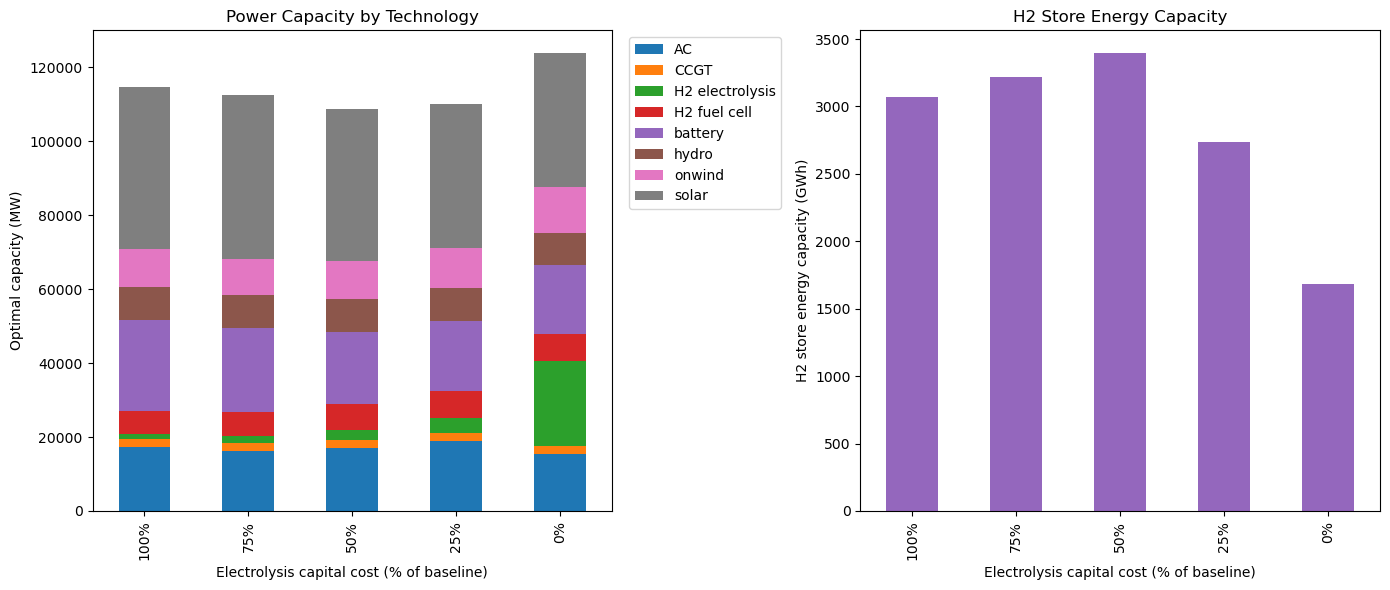

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

power_capacity_table.T.plot.bar(stacked=True, ax=axes[0])
axes[0].set_ylabel("Optimal capacity (MW)")
axes[0].set_xlabel("Electrolysis capital cost (% of baseline)")
axes[0].set_title("Power Capacity by Technology")
axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left")

if energy_capacity_table is not None:
    (energy_capacity_table.T / 1e3).plot.bar(ax=axes[1], legend=False, color="tab:purple")
    axes[1].set_ylabel("H2 store energy capacity (GWh)")
    axes[1].set_xlabel("Electrolysis capital cost (% of baseline)")
    axes[1].set_title("H2 Store Energy Capacity")

fig.tight_layout()
savefig(fig, "sensitivity", "capacity_by_technology.png")
plt.show()

## 3. Electricity Mix

In [8]:
mix_table = pd.DataFrame(
    {level: electricity_mix(net) for level, net in networks.items()}
).fillna(0)
mix_table = mix_table[sorted(mix_table.columns, reverse=True)]
mix_table.columns = [f"{c}%" for c in mix_table.columns]
mix_table.index.name = "carrier"

mix_table

,100%,75%,50%,25%,0%
carrier,,,,,
CCGT,0.000000,0.000000,0.000000,0.000000,0.000000
hydro,28.987362,29.656501,27.161753,28.855147,28.152372
onwind,15.630748,16.130993,18.487980,16.929491,16.991827
solar,55.381891,54.212506,54.350267,54.215362,54.855801


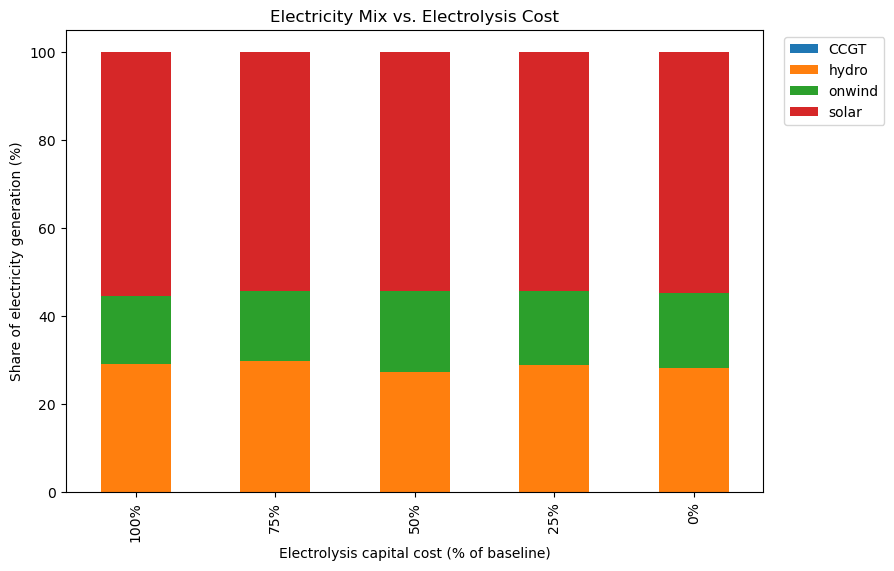

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
mix_table.T.plot.bar(stacked=True, ax=ax)
ax.set_ylabel("Share of electricity generation (%)")
ax.set_xlabel("Electrolysis capital cost (% of baseline)")
ax.set_title("Electricity Mix vs. Electrolysis Cost")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

savefig(fig, "sensitivity", "electricity_mix.png")
plt.show()

## 4. CO2 Shadow Price

The dual value (marginal cost) of the CO2 constraint: how much system cost would change per
additional tonne of CO2 allowed. Only meaningful because the CO2 cap is binding (0 t) in
every one of these scenarios.

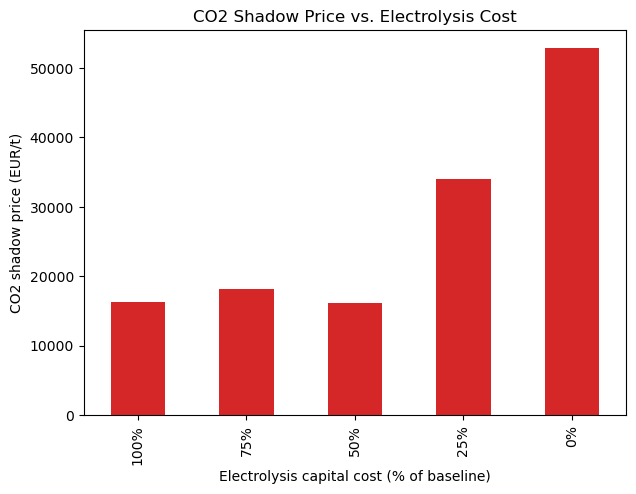

100%    16267.571095
75%     18133.129211
50%     16087.236395
25%     33968.307740
0%      52808.770236
Name: CO2 shadow price (EUR/tCO2), dtype: float64

In [10]:
shadow_price = pd.Series(
    {f"{level}%": co2_shadow_price(net, cost_scale) for level, net in networks.items()}
)
shadow_price = shadow_price.reindex(sorted(shadow_price.index, key=lambda s: -int(s.rstrip("%"))))
shadow_price.name = "CO2 shadow price (EUR/tCO2)"

fig, ax = plt.subplots(figsize=(7, 5))
shadow_price.plot.bar(ax=ax, color="tab:red")
ax.set_ylabel("CO2 shadow price (EUR/t)")
ax.set_xlabel("Electrolysis capital cost (% of baseline)")
ax.set_title("CO2 Shadow Price vs. Electrolysis Cost")

savefig(fig, "sensitivity", "co2_shadow_price.png")
plt.show()
shadow_price

## 5. Detailed Operation: 100% vs. 0% Electrolysis Cost

In [11]:
cases = {level: networks[level] for level in (100, 0) if level in networks}
if len(cases) < 2:
    print("Need both the 100% and 0% cases solved for this section - currently have:", list(cases))
cases

{100: PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 18
  - Carrier: 10
  - Generator: 28
  - GlobalConstraint: 1
  - Link: 31
  - Load: 9
  - StorageUnit: 9
  - Store: 9
  - SubNetwork: 18
 Snapshots: 1460,
 0: PyPSA Network 'Unnamed Network'
 -------------------------------
 Components:
  - Bus: 18
  - Carrier: 10
  - Generator: 28
  - GlobalConstraint: 1
  - Link: 31
  - Load: 9
  - StorageUnit: 9
  - Store: 9
  - SubNetwork: 18
 Snapshots: 1460}

Price Duration Curves

Regional electricity prices (`buses_t.marginal_price`), averaged across regions per
snapshot, then sorted in descending order against duration (hours/year).

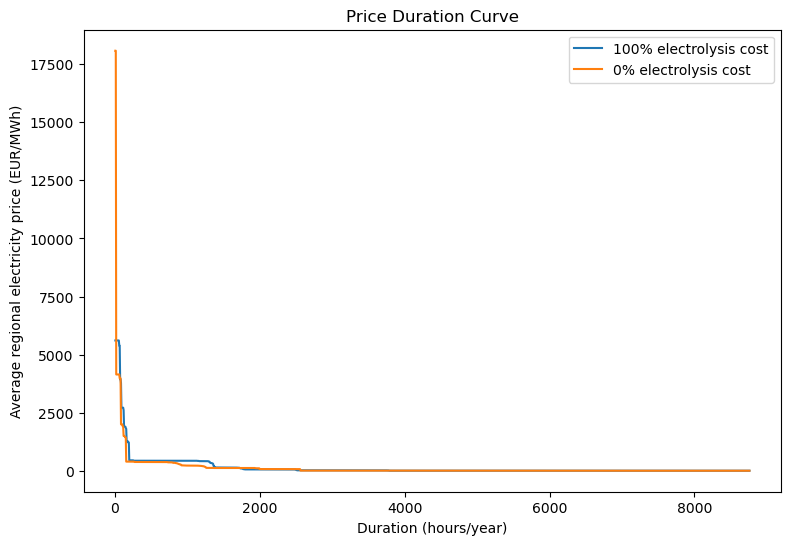

In [12]:
fig, ax = plt.subplots(figsize=(9, 6))

for level, net in cases.items():
    # buses_t.marginal_price is a dual value in the same scaled units as the objective
    # (k€, since every cost fed into the model was pre-divided by cost_scale) - multiply
    # back for a true EUR/MWh price, same as co2_shadow_price above.
    elec_prices = net.buses_t.marginal_price[electricity_buses(net)] * cost_scale
    avg_price = elec_prices.mean(axis=1)
    weighting = net.snapshot_weightings.generators
    duration = weighting.cumsum().values

    sorted_price = avg_price.sort_values(ascending=False).values
    ax.plot(duration, sorted_price, label=f"{level}% electrolysis cost")

ax.set_xlabel("Duration (hours/year)")
ax.set_ylabel("Average regional electricity price (EUR/MWh)")
ax.set_title("Price Duration Curve")
ax.legend()

savefig(fig, "sensitivity", "price_duration_curve.png")
plt.show()

Average Electricity Price per Region

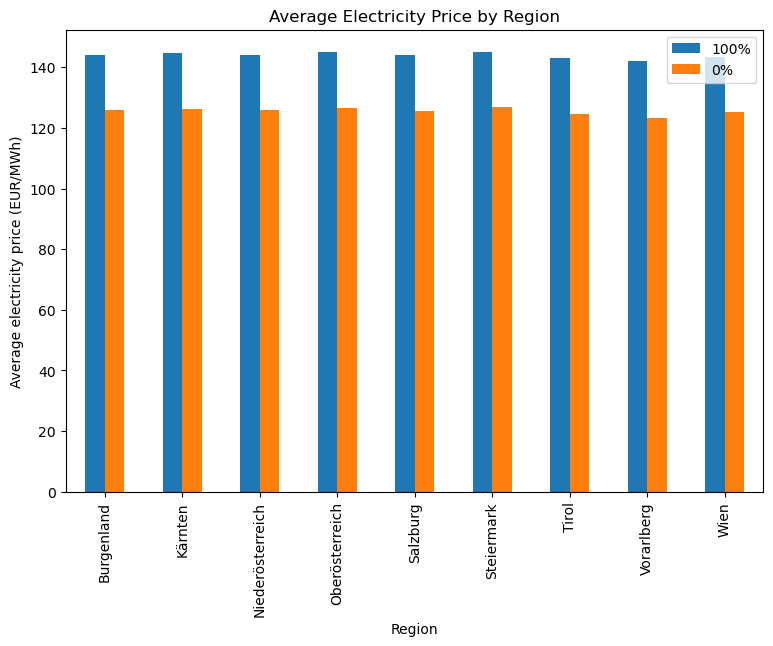

,100%,0%
name,,
Burgenland,143.987171,125.873772
Kärnten,144.786006,126.227458
Niederösterreich,143.926828,125.813429
Oberösterreich,145.129331,126.570783
Salzburg,144.173719,125.615171
Steiermark,145.045841,126.932442
Tirol,143.079534,124.520986
Vorarlberg,141.984459,123.425911
Wien,143.504054,125.390655


In [13]:
avg_regional_price = pd.DataFrame(
    {
        f"{level}%": net.buses_t.marginal_price[electricity_buses(net)].mean() * cost_scale
        for level, net in cases.items()
    }
)

fig, ax = plt.subplots(figsize=(9, 6))
avg_regional_price.plot.bar(ax=ax)
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_xlabel("Region")
ax.set_title("Average Electricity Price by Region")

savefig(fig, "sensitivity", "average_regional_price.png")
plt.show()
avg_regional_price

Curtailment Rate (Wind and Solar)

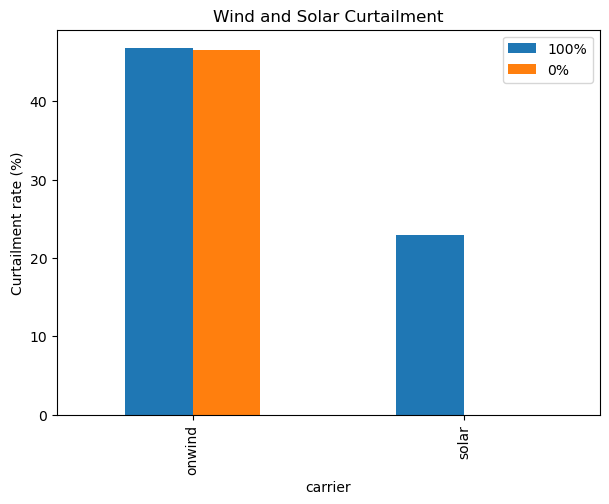

,100%,0%
carrier,,
onwind,46.804622,46.521830
solar,22.969157,0.007266


In [14]:
curtailment_table = pd.DataFrame(
    {f"{level}%": curtailment_rate(net) for level, net in cases.items()}
)

fig, ax = plt.subplots(figsize=(7, 5))
curtailment_table.plot.bar(ax=ax)
ax.set_ylabel("Curtailment rate (%)")
ax.set_title("Wind and Solar Curtailment")

savefig(fig, "sensitivity", "curtailment_rate.png")
plt.show()
curtailment_table

Storage Filling Levels Throughout the Year

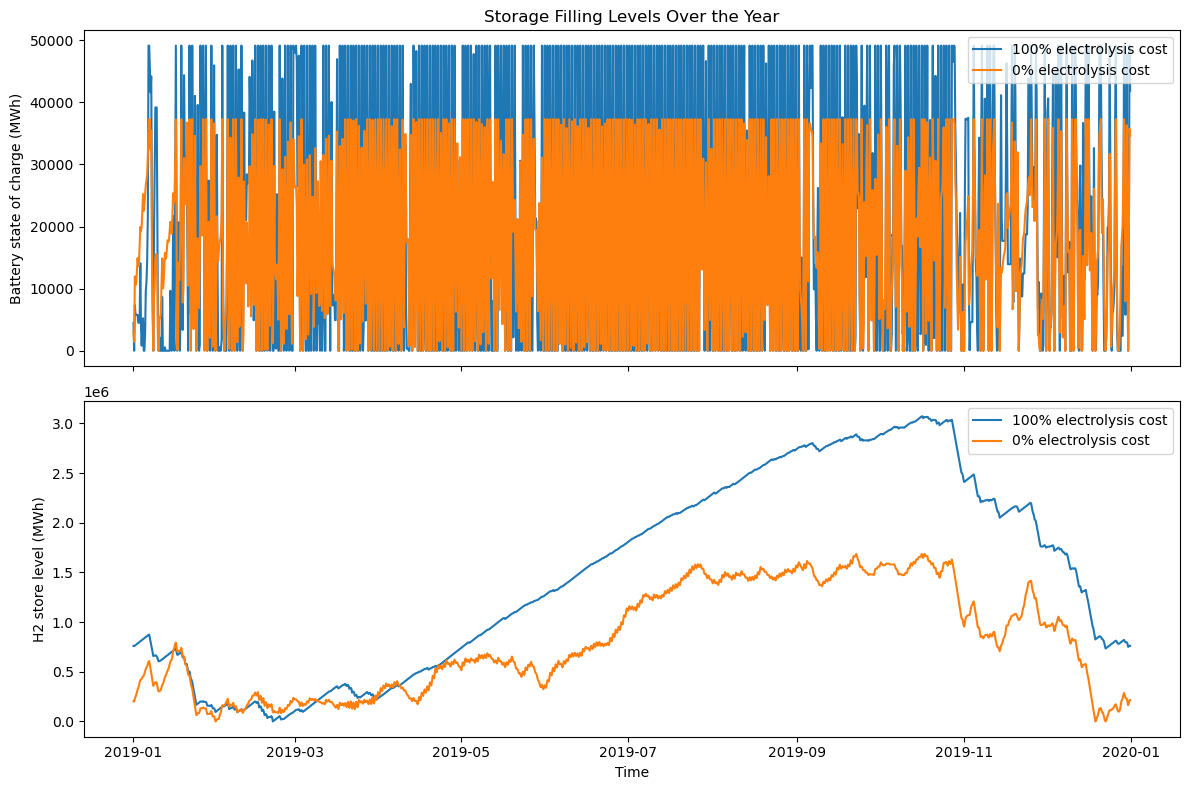

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for level, net in cases.items():
    battery_soc = net.storage_units_t.state_of_charge.sum(axis=1)
    h2_level = net.stores_t.e.sum(axis=1)
    axes[0].plot(battery_soc.index, battery_soc.values, label=f"{level}% electrolysis cost")
    axes[1].plot(h2_level.index, h2_level.values, label=f"{level}% electrolysis cost")

axes[0].set_ylabel("Battery state of charge (MWh)")
axes[0].set_title("Storage Filling Levels Over the Year")
axes[0].legend()
axes[1].set_ylabel("H2 store level (MWh)")
axes[1].set_xlabel("Time")
axes[1].legend()

fig.tight_layout()
savefig(fig, "sensitivity", "storage_filling_levels.png")
plt.show()

System Operation: Scarcity and Abundance Weeks

The scarcity/abundance weeks are picked from the weather data itself (combined wind+solar
capacity factor, unweighted mean across all generators) - this is identical across every
cost level since it only depends on ERA5 weather, not on cost assumptions.

In [16]:
reference_net = next(iter(cases.values()))
vre_gens = reference_net.generators[reference_net.generators.carrier.isin(["onwind", "solar"])].index
combined_cf = reference_net.generators_t.p_max_pu[vre_gens].mean(axis=1)

weekly_cf = combined_cf.resample("7D").mean()
scarcity_week_start = weekly_cf.idxmin()
abundance_week_start = weekly_cf.idxmax()

print("scarcity week starting: ", scarcity_week_start, f"(avg VRE CF = {weekly_cf.min():.2%})")
print("abundance week starting:", abundance_week_start, f"(avg VRE CF = {weekly_cf.max():.2%})")

scarcity week starting:  2019-11-05 00:00:00 (avg VRE CF = 7.34%)
abundance week starting: 2019-04-23 00:00:00 (avg VRE CF = 20.02%)


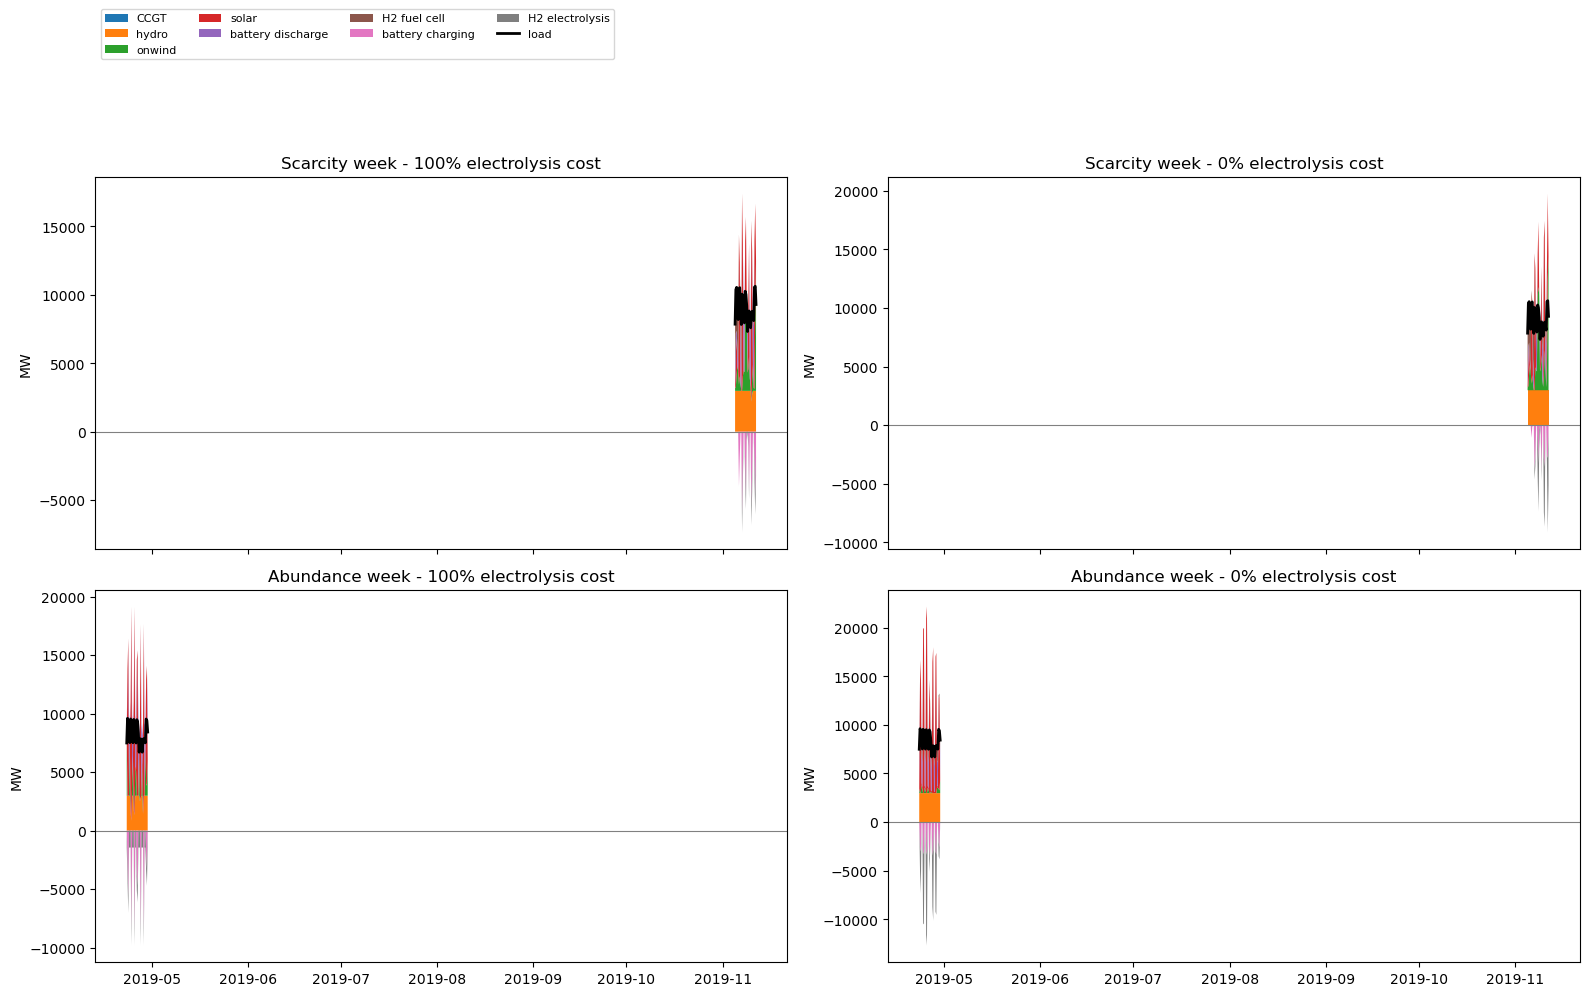

In [17]:
def plot_operation_week(network, week_start, title, ax):
    week_end = week_start + pd.Timedelta(days=7)
    snapshots = network.snapshots[(network.snapshots >= week_start) & (network.snapshots < week_end)]

    gen = network.generators_t.p.loc[snapshots].T.groupby(network.generators.carrier).sum().T

    battery_p = network.storage_units_t.p.loc[snapshots].sum(axis=1)
    battery_discharge = battery_p.clip(lower=0)
    battery_charge = battery_p.clip(upper=0)

    elec_links = network.links[network.links.carrier == "H2 electrolysis"].index
    fc_links = network.links[network.links.carrier == "H2 fuel cell"].index
    electrolysis_draw = network.links_t.p0.loc[snapshots, elec_links].sum(axis=1)  # positive = consumption
    fuel_cell_output = -network.links_t.p1.loc[snapshots, fc_links].sum(axis=1)  # positive = supply

    load = network.loads_t.p_set.loc[snapshots].sum(axis=1)

    positive_stack = pd.concat(
        [gen, battery_discharge.rename("battery discharge"), fuel_cell_output.rename("H2 fuel cell")],
        axis=1,
    ).clip(lower=0)
    negative_stack = pd.concat(
        [battery_charge.rename("battery charging"), (-electrolysis_draw).rename("H2 electrolysis")],
        axis=1,
    ).clip(upper=0)

    ax.stackplot(snapshots, positive_stack.T, labels=positive_stack.columns)
    ax.stackplot(snapshots, negative_stack.T, labels=negative_stack.columns)
    ax.plot(snapshots, load.values, color="black", linewidth=2, label="load")
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("MW")


fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex="col")

for col, (level, net) in enumerate(cases.items()):
    plot_operation_week(net, scarcity_week_start, f"Scarcity week - {level}% electrolysis cost", axes[0, col])
    plot_operation_week(net, abundance_week_start, f"Abundance week - {level}% electrolysis cost", axes[1, col])

axes[0, 0].legend(bbox_to_anchor=(0, 1.3), loc="lower left", ncol=4, fontsize=8)
fig.tight_layout()
savefig(fig, "sensitivity", "operation_weeks.png")
plt.show()